# **workshop1**

In [2]:
import numpy as np

from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]] # la transformation qui va faire que les blobs soient anisotropes,
# En appliquant cette transformation, les blobs générés par make_blobs seront étirés et orientés de manière à créer des clusters anisotropes, 
#  ce qui peut être utile pour tester la robustesse des algorithmes de clustering face à des données non isotropes.
X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # np.dot est utilisé pour appliquer la transformation linéaire aux données générées, ce qui crée des clusters anisotropes.
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # cluster_std permet de spécifier l'écart type de chaque cluster, ce qui crée des clusters de tailles différentes

X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # np.vstack est utilisé pour empiler verticalement les échantillons filtrés de chaque cluster, créant ainsi un nouveau jeu de données avec un nombre réduit d'échantillons pour chaque cluster.
y_filtered = [0] * 500 + [1] * 100 + [2] * 10
# y_filtered est une liste qui contient les étiquettes correspondantes pour les échantillons filtrés, indiquant à quel cluster chaque échantillon appartient.

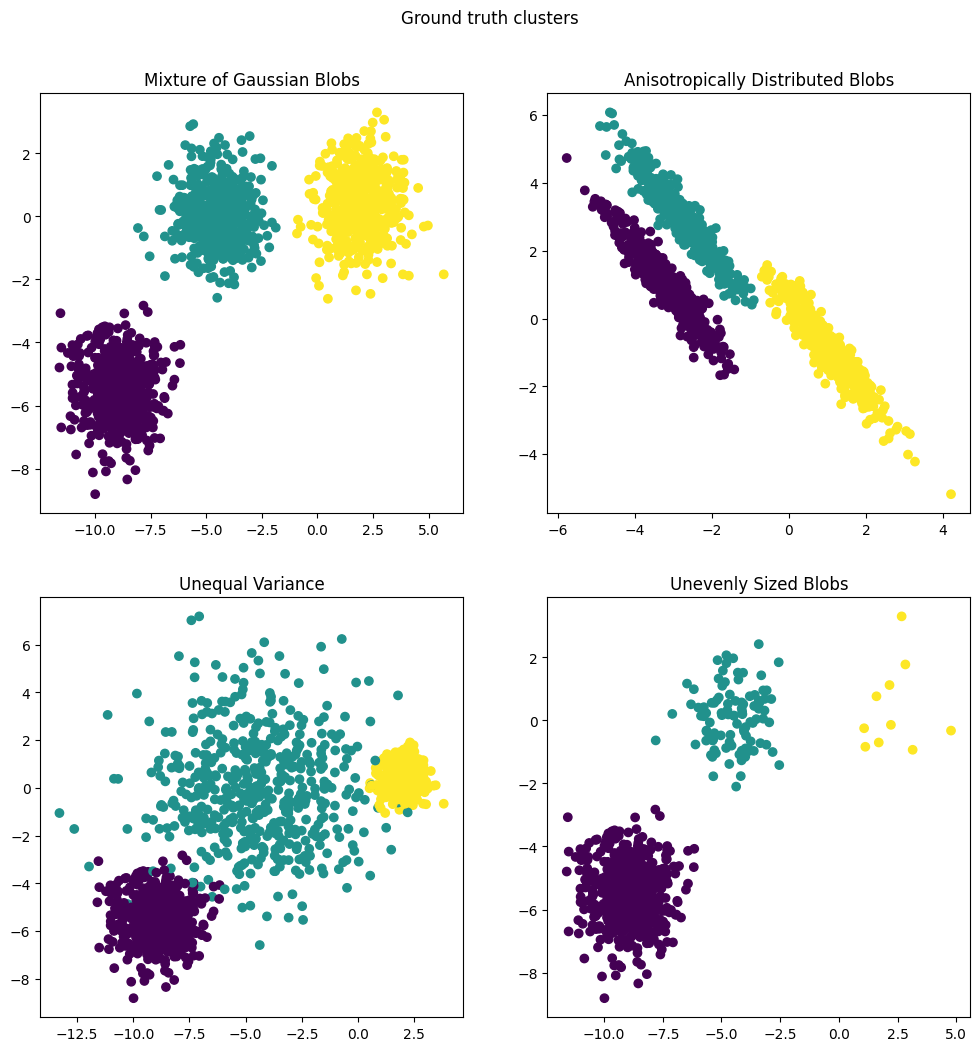

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12)) # plt.subplots est utilisé pour créer une figure avec une grille de sous-graphiques (2x2 dans ce cas),
# et axs est un tableau d'axes qui permet de référencer chaque sous-graphe individuellement pour y tracer les données.

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y) # axs[0, 0].scatter est utilisé pour créer un nuage de points dans le premier sous-graphe (en haut à gauche) en utilisant les données originales X et les étiquettes y pour colorer les points en fonction de leur cluster d'appartenance.
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

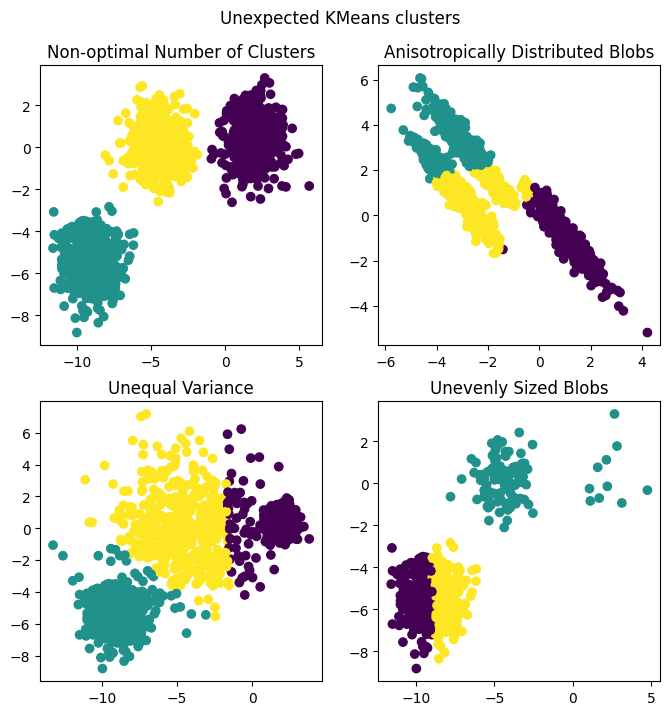

In [6]:
from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
    "random_state": random_state,
}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X) # KMeans est utilisé pour effectuer le clustering sur les données originales X en spécifiant n_clusters=3, ce qui signifie que l'algorithme va essayer de trouver 3 clusters dans les données, ce qui est un nombre optimal de clusters pour ce jeu de données.
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_pred)
axs[0, 0].set_title("Non-optimal Number of Clusters")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_aniso)
axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_varied)
axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
axs[1, 0].set_title("Unequal Variance")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_filtered)
axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Unexpected KMeans clusters").set_y(0.95)
plt.show()

on vois la " performance" de kmeans en fonction du tyoe de données que l'on a

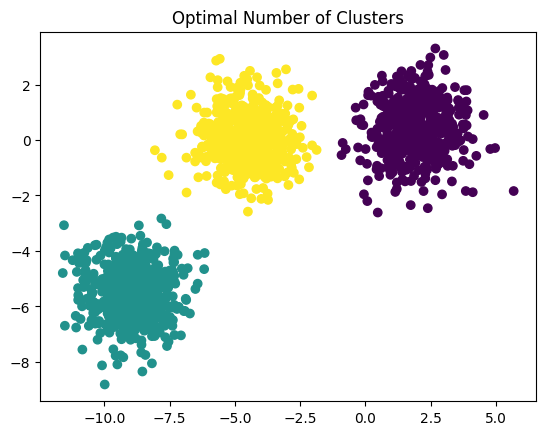

In [7]:
y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Optimal Number of Clusters")
plt.show()

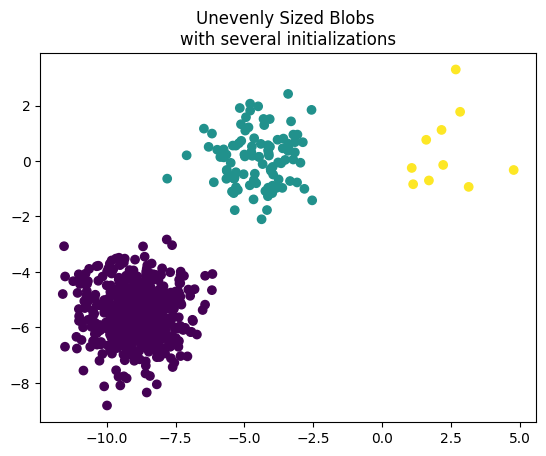

In [ ]:
y_pred = KMeans(n_clusters=3, n_init=10, random_state=random_state).fit_predict(
    X_filtered
) # on rajoute n_init=10 pour faire plusieurs initialisations de KMeans, ce qui peut aider à trouver une meilleure solution de clustering, 
#surtout lorsque les données sont difficiles à clusteriser, comme c'est le cas avec les blobs de tailles inégales.
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("Unevenly Sized Blobs \nwith several initializations")
plt.show()

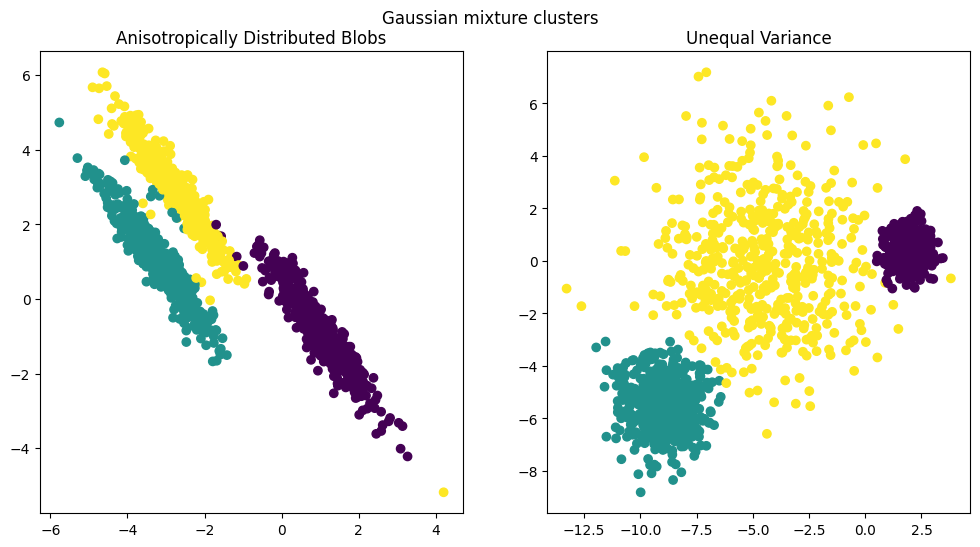

In [10]:
from sklearn.mixture import GaussianMixture

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# GaussianMixture est utilisé pour les données de forme disverse et nebuleuse (distribution normal, dense au centre mais qui s'eparille au fur et a mersure)
ax1.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
ax1.set_title("Anisotropically Distributed Blobs")

y_pred = GaussianMixture(n_components=3).fit_predict(X_varied)
ax2.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
ax2.set_title("Unequal Variance")

plt.suptitle("Gaussian mixture clusters").set_y(0.95)
plt.show()